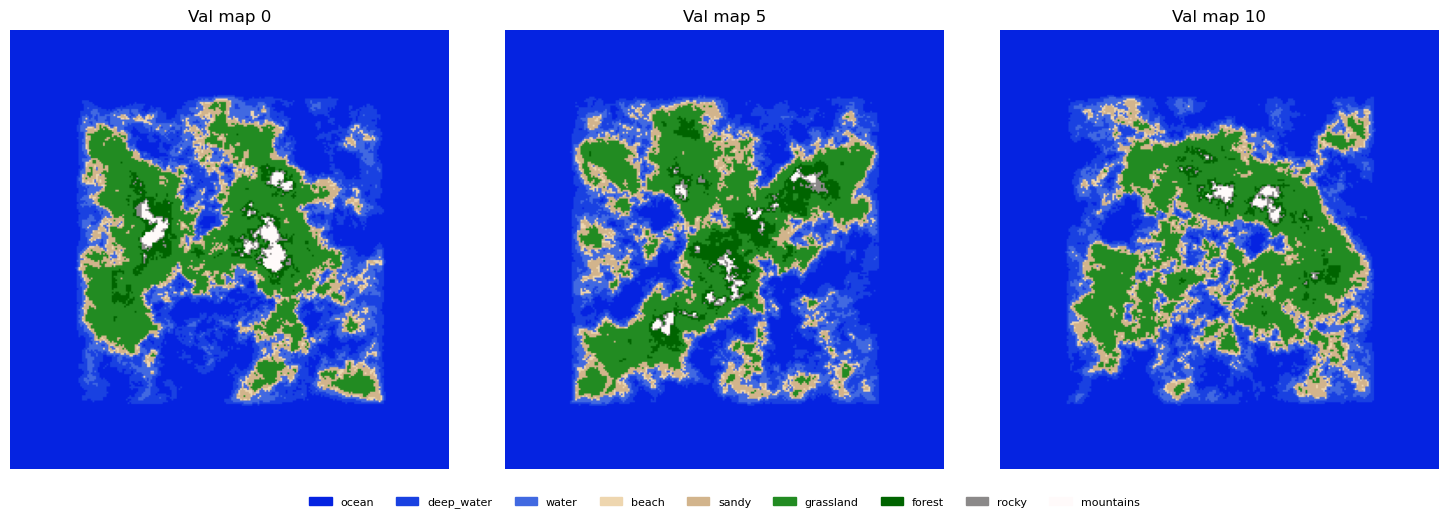

In [139]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from cogniland.env.types import EnvConfig, RewardConfig, TerrainDef, AgentConfig

# Terrain definitions matching configs/env/default.yaml
TERRAINS = (
    TerrainDef("ocean",      0.007, 5.0,  -1.5, 0.0,  16, (5,35,225),     ("water",)),
    TerrainDef("deep_water", 0.025, 4.0,  -1.0, 0.0,  12, (25,65,225),    ("water",)),
    TerrainDef("water",      0.05,  2.0,  -0.5, 0.0,  10, (65,105,225),   ("water",)),
    TerrainDef("beach",      0.06,  2.0,  -1.0, 0.0,  7, (238,214,175),   ("land",)),
    TerrainDef("sandy",      0.1,   2.5,  -1.0, 0.0,  7, (210,180,140),   ("land",)),
    TerrainDef("grassland",  0.25,  3.25, -1.0, 0.0,  7, (34,139,34),     ("land",)),
    TerrainDef("forest",     0.6,   4.0,   5.0, 5.0,  5, (0,100,0),       ("land","forest")),
    TerrainDef("rocky",      0.7,   4.5,  -2.0, 0.0, 10, (139,137,137),   ("land",)),
    TerrainDef("mountains",  1.0,   5.0,  -5.0, 0.0, 22, (255,250,250),   ("land",)),
)

config = EnvConfig(
    terrains=TERRAINS,
    reward=RewardConfig(
        reach_bonus=150.0, lambda_p=0.04,
        lambda_s=0.001, lambda_t=40.0, lambda_d=1.0, beta_raft=30.0,
    ),
)
compiled = config.compile_terrain("cpu")

# Load validation maps
val_maps = torch.load("../data/val_seed42_n16.pt", map_location="cpu", weights_only=True)['maps']  # [16, 250, 250]
MAP_IDS = [0, 5, 10]
maps = [val_maps[i] for i in MAP_IDS]

# Vectorized colorization
thresholds_np = compiled.thresholds.numpy()
color_lut_np = compiled.color_lut.numpy()
move_costs_np = compiled.move_costs.numpy()
res_rate_np = compiled.res_rate.numpy()
hp_rate_np = compiled.hp_rate.numpy()
is_water_np = compiled.is_water.numpy()
is_forest_np = compiled.is_forest.numpy()
terrain_names = compiled.terrain_names

def colorize(hm):
    tidx = np.searchsorted(thresholds_np, hm.numpy().ravel(), side="left").reshape(hm.shape)
    tidx = np.clip(tidx, 0, compiled.num_terrains - 1)
    return color_lut_np[tidx]

def terrain_map(hm):
    tidx = np.searchsorted(thresholds_np, hm.numpy().ravel(), side="left").reshape(hm.shape)
    return np.clip(tidx, 0, compiled.num_terrains - 1)

# Plot 3 maps
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, m, mid in zip(axes, maps, MAP_IDS):
    ax.imshow(colorize(m))
    ax.set_title(f"Val map {mid}", fontsize=12)
    ax.axis("off")

# Terrain legend
patches = [mpatches.Patch(color=np.array(t.color)/255, label=t.name) for t in TERRAINS]
fig.legend(handles=patches, loc="lower center", ncol=9, fontsize=8, frameon=False)
fig.subplots_adjust(bottom=0.12)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

Edge Costs (Reward Graph)Edge cost from cell A to neighbor B: `move_cost[terrain(B)] + beta_raft * 1_{land(A) & water(B)}`

The raft penalty (beta_raft=20) makes land-to-water transitions expensive in the cost-to-go computation.

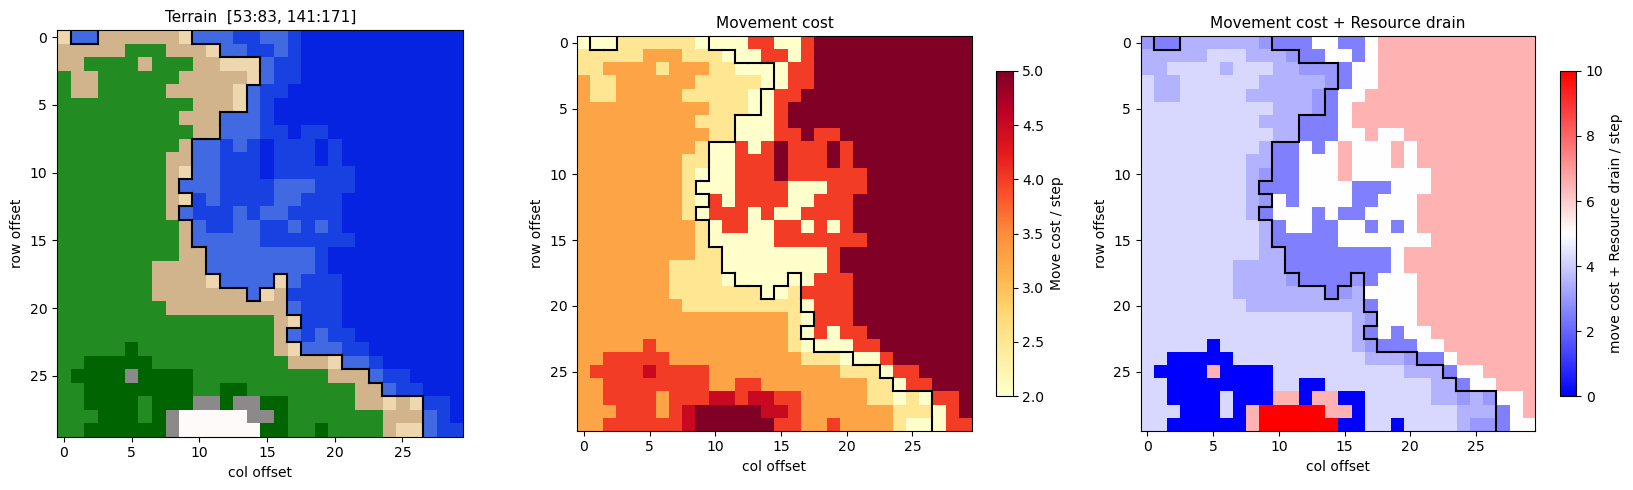

In [140]:
# Find a cutout region on map 0 that includes a land-water boundary
tmap0 = terrain_map(maps[0])
water_mask = is_water_np[tmap0]

SIZE = 30
best_r, best_c, best_score = 0, 0, 0
for r in range(50, 200):
    for c in range(50, 200):
        patch = water_mask[r:r+SIZE, c:c+SIZE]
        if patch.shape != (SIZE, SIZE):
            continue
        frac = patch.mean()
        score = frac * (1 - frac)
        if score > best_score:
            best_score = score
            best_r, best_c = r, c

r0, c0 = best_r, best_c
cutout = maps[0][r0:r0+SIZE, c0:c0+SIZE]
tcut = tmap0[r0:r0+SIZE, c0:c0+SIZE]

move_cost_map = move_costs_np[tcut]
res_cost_map = np.maximum(0, move_costs_np[tcut] - res_rate_np[tcut])  # positive = drain per step, negative = 0
water_patch = is_water_np[tcut]


def draw_land_water_boundary(ax, water_mask):
    """Draw black line segments on edges between land and water pixels."""
    H, W = water_mask.shape
    for r in range(H):
        for c in range(W):
            # right neighbor
            if c + 1 < W and water_mask[r, c] != water_mask[r, c + 1]:
                ax.plot([c + 0.5, c + 0.5], [r - 0.5, r + 0.5],
                        color="k", linewidth=1.5)
            # bottom neighbor
            if r + 1 < H and water_mask[r, c] != water_mask[r + 1, c]:
                ax.plot([c - 0.5, c + 0.5], [r + 0.5, r + 0.5],
                        color="k", linewidth=1.5)


ext = [-0.5, SIZE - 0.5, SIZE - 0.5, -0.5]
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5))

# Left: terrain cutout
ax1.imshow(colorize(cutout), interpolation="nearest", extent=ext)
draw_land_water_boundary(ax1, water_patch)
ax1.set_title(f"Terrain  [{r0}:{r0+SIZE}, {c0}:{c0+SIZE}]", fontsize=11)
ax1.set_xlabel("col offset"); ax1.set_ylabel("row offset")

# Middle: movement cost heatmap
im2 = ax2.imshow(move_cost_map, cmap="YlOrRd", interpolation="nearest", extent=ext)
draw_land_water_boundary(ax2, water_patch)
fig.colorbar(im2, ax=ax2, shrink=0.8, label="Move cost / step")
ax2.set_title("Movement cost", fontsize=11)
ax2.set_xlabel("col offset"); ax2.set_ylabel("row offset")

# Right: resource drain heatmap (negative res_rate = drain)
im3 = ax3.imshow(res_cost_map, cmap="bwr", interpolation="nearest", extent=ext)
draw_land_water_boundary(ax3, water_patch)
fig.colorbar(im3, ax=ax3, shrink=0.8, label="move cost + Resource drain / step")
ax3.set_title("Movement cost + Resource drain", fontsize=11)
ax3.set_xlabel("col offset"); ax3.set_ylabel("row offset")

plt.tight_layout()
plt.show()

Spawn & Target Selection Edit spawn/target coordinates below, then re-run the cells that follow.

In [141]:
# (row, col) coordinates — edit these and re-run cells below
spawns = [
    (160, 140),  # map 0
    (171, 65),  # map 5
    (150, 175),  # map 10
]
targets = [
    (55, 125),   # map 0
    (64, 125),   # map 5
    (80, 125),   # map 10
]

# Validate: check that spawn & target are on land
land_threshold = compiled.land_threshold
for i, (m, s, t) in enumerate(zip(maps, spawns, targets)):
    s_h = m[s[0], s[1]].item()
    t_h = m[t[0], t[1]].item()
    s_tidx = min(np.searchsorted(thresholds_np, s_h, side="left"), compiled.num_terrains - 1)
    t_tidx = min(np.searchsorted(thresholds_np, t_h, side="left"), compiled.num_terrains - 1)
    s_ok = "OK" if s_h > land_threshold else "WARNING: water!"
    t_ok = "OK" if t_h > land_threshold else "WARNING: water!"
    print(f"Map {MAP_IDS[i]:>2d}:  spawn ({s[0]:>3d},{s[1]:>3d}) = {terrain_names[s_tidx]:<12s} {s_ok}"
          f"  |  target ({t[0]:>3d},{t[1]:>3d}) = {terrain_names[t_tidx]:<12s} {t_ok}")

Map  0:  spawn (160,140) = water        WARNING: water!  |  target ( 55,125) = grassland    OK
Map  5:  spawn (171, 65) = grassland    OK  |  target ( 64,125) = grassland    OK
Map 10:  spawn (150,175) = forest       OK  |  target ( 80,125) = grassland    OK


## Reverse Dijkstra + Optimal Path

Edge cost = `max(0.1, move_cost - res_rate) + beta_raft * 1_{land→water}`

Terrain      move_cost  res_rate  edge_cost
--------------------------------------------
ocean             5.00     -1.50       6.50
deep_water        4.00     -1.00       5.00
water             2.00     -0.50       2.50
beach             2.00     -1.00       3.00
sandy             2.50     -1.00       3.50
grassland         3.25     -1.00       4.25
forest            4.00     +5.00       0.10
rocky             4.50     -2.00       6.50
mountains         5.00     -5.00      10.00
Map 0: 157 steps
Map 5: 200 steps
Map 10: 137 steps


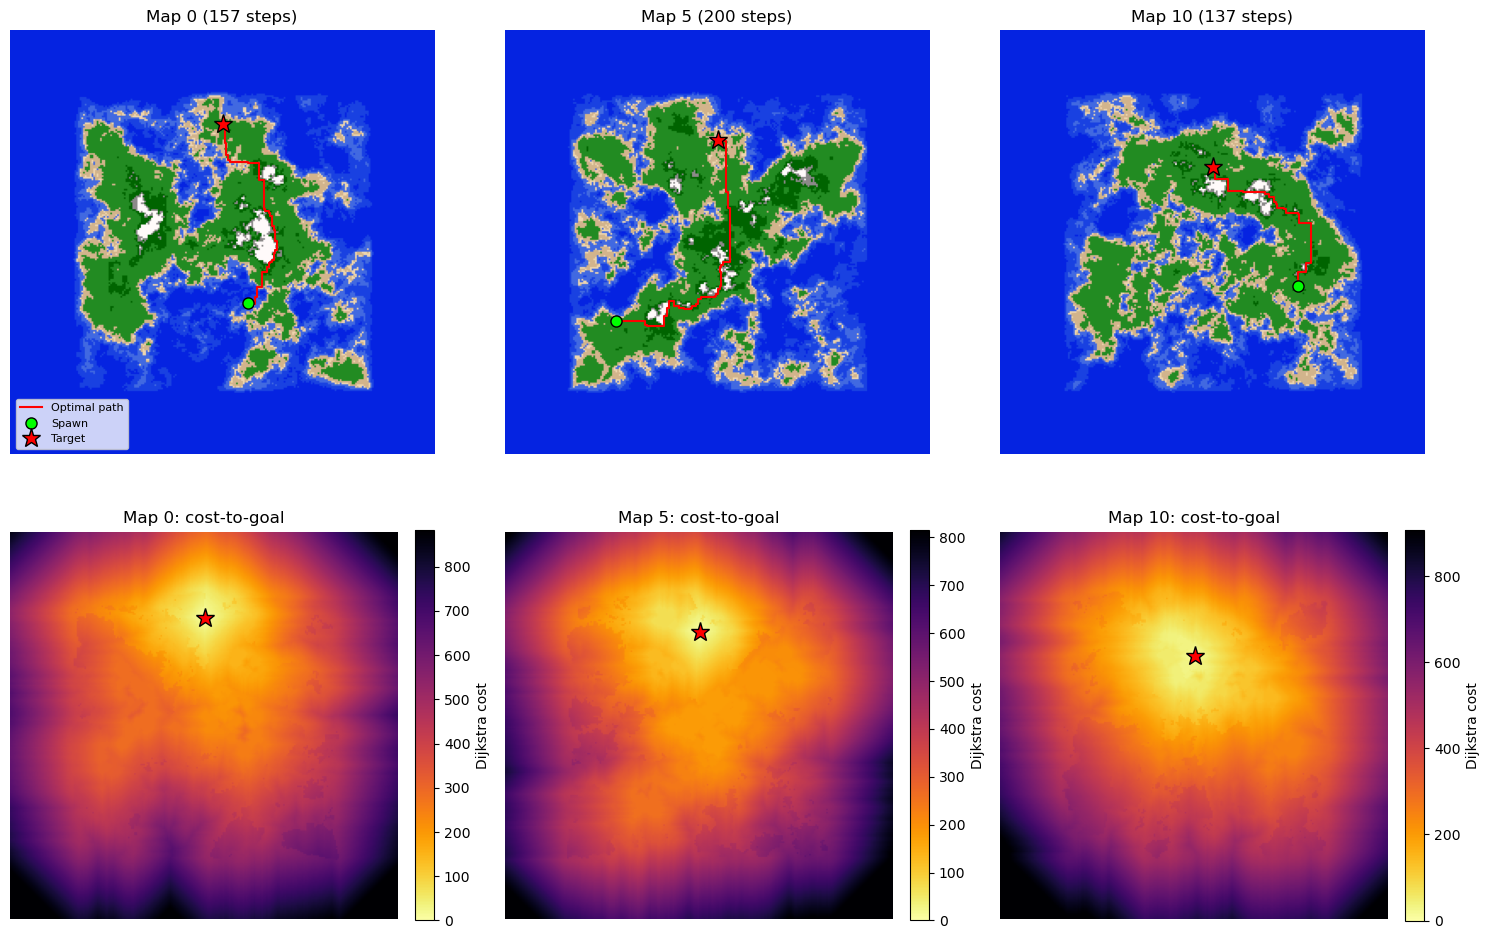

In [142]:
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra as scipy_dijkstra

# Edge costs: max(0.1, move_cost - res_rate) per terrain
print(f"{'Terrain':<12s} {'move_cost':>9s} {'res_rate':>9s} {'edge_cost':>10s}")
print("-" * 44)
for t in TERRAINS:
    edge = max(0.1, t.move_cost - t.res_rate)
    print(f"{t.name:<12s} {t.move_cost:>9.2f} {t.res_rate:>+9.2f} {edge:>10.2f}")

def build_resource_aware_graph(wm, terrains, beta_raft):
    """edge cost = max(0.1, move_cost - res_rate) + raft."""
    H, W = wm.shape
    thresholds = np.array([t.threshold for t in terrains])
    is_water = np.array(["water" in t.tags for t in terrains])
    edge_costs = np.array([max(0.1, t.move_cost - t.res_rate) for t in terrains])

    terrain = np.searchsorted(thresholds, wm.ravel(), side="left").reshape(H, W)
    terrain = np.clip(terrain, 0, len(thresholds) - 1).astype(np.int32)
    water_mask = is_water[terrain]

    r_h, c_h = np.mgrid[0:H, 0:W-1]
    src_h = (r_h * W + c_h).ravel()
    dst_h = (r_h * W + c_h + 1).ravel()
    cost_h_fwd = edge_costs[terrain[r_h, c_h + 1]].ravel()
    raft_h_fwd = (~water_mask[r_h, c_h] & water_mask[r_h, c_h + 1]).ravel().astype(np.float64) * beta_raft
    cost_h_bwd = edge_costs[terrain[r_h, c_h]].ravel()
    raft_h_bwd = (~water_mask[r_h, c_h + 1] & water_mask[r_h, c_h]).ravel().astype(np.float64) * beta_raft

    r_v, c_v = np.mgrid[0:H-1, 0:W]
    src_v = (r_v * W + c_v).ravel()
    dst_v = ((r_v + 1) * W + c_v).ravel()
    cost_v_fwd = edge_costs[terrain[r_v + 1, c_v]].ravel()
    raft_v_fwd = (~water_mask[r_v, c_v] & water_mask[r_v + 1, c_v]).ravel().astype(np.float64) * beta_raft
    cost_v_bwd = edge_costs[terrain[r_v, c_v]].ravel()
    raft_v_bwd = (~water_mask[r_v + 1, c_v] & water_mask[r_v, c_v]).ravel().astype(np.float64) * beta_raft

    all_src  = np.concatenate([src_h, dst_h, src_v, dst_v])
    all_dst  = np.concatenate([dst_h, src_h, dst_v, src_v])
    all_data = np.concatenate([
        cost_h_fwd + raft_h_fwd, cost_h_bwd + raft_h_bwd,
        cost_v_fwd + raft_v_fwd, cost_v_bwd + raft_v_bwd,
    ])
    N = H * W
    return csr_matrix((all_data, (all_src, all_dst)), shape=(N, N))

# Greedy path tracer on cost-to-go map
DELTAS = [(-1, 0), (1, 0), (0, 1), (0, -1)]

def trace_optimal_path(ctg, spawn, target, max_steps=5000):
    path = [spawn]
    r, c = spawn
    H, W = ctg.shape
    for _ in range(max_steps):
        if (r, c) == target:
            break
        best_cost, best_next = ctg[r, c], None
        for dr, dc in DELTAS:
            nr, nc = r + dr, c + dc
            if 0 <= nr < H and 0 <= nc < W and ctg[nr, nc] < best_cost:
                best_cost = ctg[nr, nc]
                best_next = (nr, nc)
        if best_next is None:
            break
        r, c = best_next
        path.append((r, c))
    return path

# Reverse Dijkstra with resource-aware costs
world_maps_t = torch.stack(maps)
targets_t = torch.tensor(targets, dtype=torch.long)

ctg_maps = []
for i in range(3):
    wm = maps[i].numpy()
    H, W = wm.shape
    graph = build_resource_aware_graph(wm, TERRAINS, config.reward.beta_raft)
    tr, tc = targets[i]
    target_idx = tr * W + tc
    dist = scipy_dijkstra(graph.T, directed=True, indices=target_idx)
    ctg_maps.append(dist.reshape(H, W))

paths = []
for i in range(3):
    p = trace_optimal_path(ctg_maps[i], spawns[i], targets[i])
    paths.append(p)
    print(f"Map {MAP_IDS[i]}: {len(p)} steps")

# Plot: top row = map + path, bottom row = cost-to-go heatmap
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, (m, p, sp, tg, mid, ctg) in enumerate(zip(maps, paths, spawns, targets, MAP_IDS, ctg_maps)):
    ax_map = axes[0, i]
    ax_ctg = axes[1, i]

    # Top: terrain map with optimal path overlay
    ax_map.imshow(colorize(m))
    cols = [c for r, c in p]
    rows = [r for r, c in p]
    ax_map.plot(cols, rows, "r-", linewidth=1.5, label="Optimal path")
    ax_map.plot(sp[1], sp[0], "o", color="lime", markersize=8, markeredgecolor="k", label="Spawn")
    ax_map.plot(tg[1], tg[0], "r*", markersize=14, markeredgecolor="k", label="Target")
    ax_map.set_title(f"Map {mid} ({len(p)} steps)", fontsize=12)
    ax_map.axis("off")

    # Bottom: Dijkstra cost-to-go heatmap (inf = unreachable, shown as black)
    ctg_display = np.where(np.isinf(ctg), np.nan, ctg)
    im = ax_ctg.imshow(ctg_display, cmap="inferno_r", origin="upper",
                       vmin=np.nanmin(ctg_display), vmax=np.nanpercentile(ctg_display, 98))
    ax_ctg.plot(tg[1], tg[0], "r*", markersize=14, markeredgecolor="k")
    ax_ctg.set_title(f"Map {mid}: cost-to-goal", fontsize=12)
    ax_ctg.axis("off")
    plt.colorbar(im, ax=ax_ctg, fraction=0.046, pad=0.04, label="Dijkstra cost")

axes[0, 0].legend(loc="lower left", fontsize=8, framealpha=0.8)
plt.tight_layout()
plt.show()

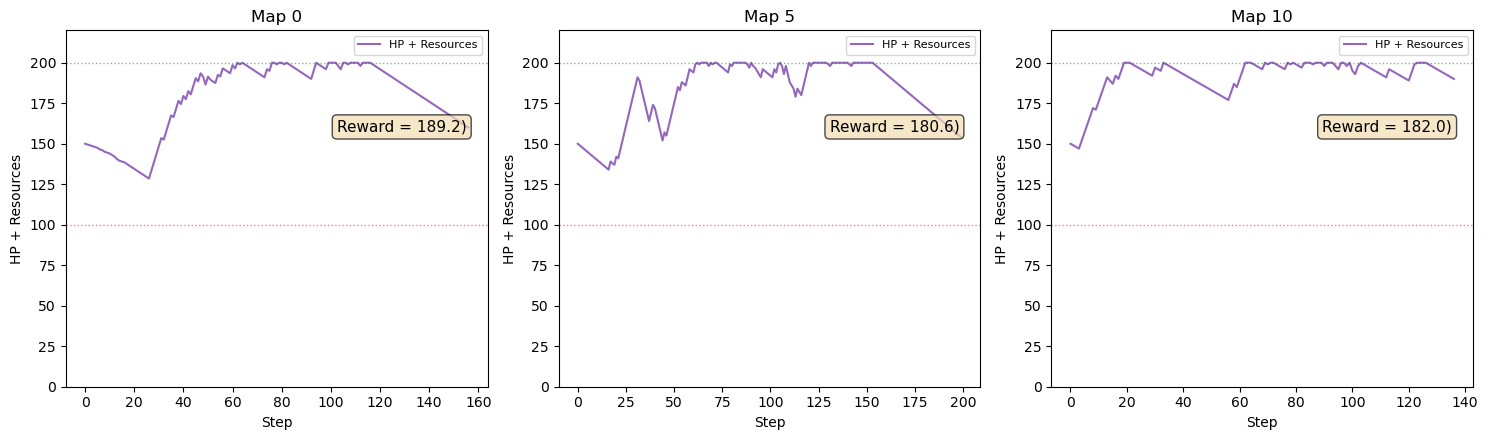

In [143]:
def simulate_walk(path, heightmap, ctg, config, compiled_np):
    """Simulate agent HP/resources/reward along a given path.

    Mirrors core.py: apply_terrain_effects (lines 228-270) and
    compute_reward (lines 116-159).
    """
    mc = compiled_np["move_costs"]
    rr = compiled_np["res_rate"]
    hr = compiled_np["hp_rate"]
    iw = compiled_np["is_water"]
    if_ = compiled_np["is_forest"]
    th = compiled_np["thresholds"]

    rw = config.reward
    ag = config.agent

    # Precompute terrain index for each cell on the path
    hm = heightmap.numpy()
    tidx_path = [
        min(np.searchsorted(th, hm[r, c], side="left"), len(th) - 1)
        for r, c in path
    ]

    hp = ag.init_hp
    resources = ag.init_resources
    cost = 0.0
    prev_ctg = ctg[path[0]]
    dijkstra_cost = ctg[path[0]]  # cost-to-go at spawn = optimal total cost

    hp_hist = [hp]
    res_hist = [resources]
    reward_hist = [0.0]
    cumul = 0.0

    for t in range(1, len(path)):
        old_tidx = tidx_path[t - 1]
        new_tidx = tidx_path[t]

        # 1. Movement cost
        cost += mc[new_tidx]

        # 2. Resource drain (core.py lines 240-245)
        drain = max(0.0, -rr[new_tidx])
        actual_drain = min(resources, drain)
        resources -= actual_drain
        hp -= (drain - actual_drain) * ag.no_res_hp_multiplier

        # 3. Forest mechanic (core.py lines 248-257)
        if if_[new_tidx]:
            if hp < ag.max_hp:
                hp += hr[new_tidx]
            else:
                resources += max(0.0, rr[new_tidx])

        # 4. Land-to-water transition (core.py lines 260-268)
        if not iw[old_tidx] and iw[new_tidx]:
            avail = min(resources, ag.land_to_water_resource_cost)
            missing = ag.land_to_water_resource_cost - avail
            resources -= avail
            hp -= missing * ag.no_res_hp_multiplier

        # 5. Clamp
        hp = np.clip(hp, 0.0, ag.max_hp)
        resources = np.clip(resources, 0.0, ag.max_resources)

        # 6. Cost-to-go and risk (core.py lines 86-90)
        new_ctg = ctg[path[t]]
        drain_now = max(0.0, -rr[new_tidx])
        budget = resources + 0.5 * hp
        risk = drain_now / max(drain_now + budget, 1e-6)

        # 7. Reward (core.py lines 116-159)
        r_progress = rw.lambda_p * (prev_ctg - new_ctg)
        r_step = -rw.lambda_s

        reached = path[t] == path[-1] and t == len(path) - 1
        alive = hp > 0

        time_ratio = np.clip(dijkstra_cost / max(cost, 1e-6), 0.0, 1.0)
        r_success = (rw.reach_bonus + rw.lambda_t * time_ratio) if reached else 0.0
        r_death = (-rw.lambda_d * rw.reach_bonus) if not alive else 0.0

        reward_t = r_progress  + r_step + r_success + r_death
        cumul += reward_t

        hp_hist.append(hp)
        res_hist.append(resources)
        reward_hist.append(cumul)
        prev_ctg = new_ctg

        if hp <= 0:
            break

    return np.array(hp_hist), np.array(res_hist), np.array(reward_hist)


# Numpy arrays for compiled terrain data
compiled_np = dict(
    move_costs=move_costs_np, res_rate=res_rate_np, hp_rate=hp_rate_np,
    is_water=is_water_np, is_forest=is_forest_np, thresholds=thresholds_np,
)

# Run simulation and plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for i, (ax, path, m, mid) in enumerate(zip(axes, paths, maps, MAP_IDS)):
    hp_h, res_h, rew_h = simulate_walk(path, m, ctg_maps[i], config, compiled_np)
    steps = np.arange(len(hp_h))

    budget = hp_h + res_h
    ax.plot(steps, budget, color="tab:purple", linewidth=1.5, label="HP + Resources")
    ax.axhline(config.agent.max_hp + config.agent.max_resources, linestyle=":", color="green", alpha=0.5, linewidth=1)
    ax.axhline(100, linestyle=":", color="red", alpha=0.5, linewidth=1)
    ax.set_ylim(0, config.agent.max_hp + config.agent.max_resources + 20)
    ax.set_xlabel("Step")
    ax.set_ylabel("HP + Resources")
    ax.set_title(f"Map {mid}", fontsize=12)
    ax.legend(loc="upper right", fontsize=8)

    # Annotate cumulative reward
    ax.annotate(
        f"Reward = {rew_h[-1]:.1f})",
        xy=(0.95, 0.75), xycoords="axes fraction",
        ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.3", fc="wheat", alpha=0.7),
    )

plt.tight_layout()
plt.show()

In [144]:
# (row, col) coordinates — edit these and re-run cells below
spawns = [
    (80, 100),  # map 0
    (80, 160),  # map 5
    (130, 75),  # map 10
]
targets = [
    (55, 125),   # map 0
    (64, 105),   # map 5
    (80, 125),   # map 10
]


Map 0: 51 steps
Map 5: 144 steps
Map 10: 103 steps


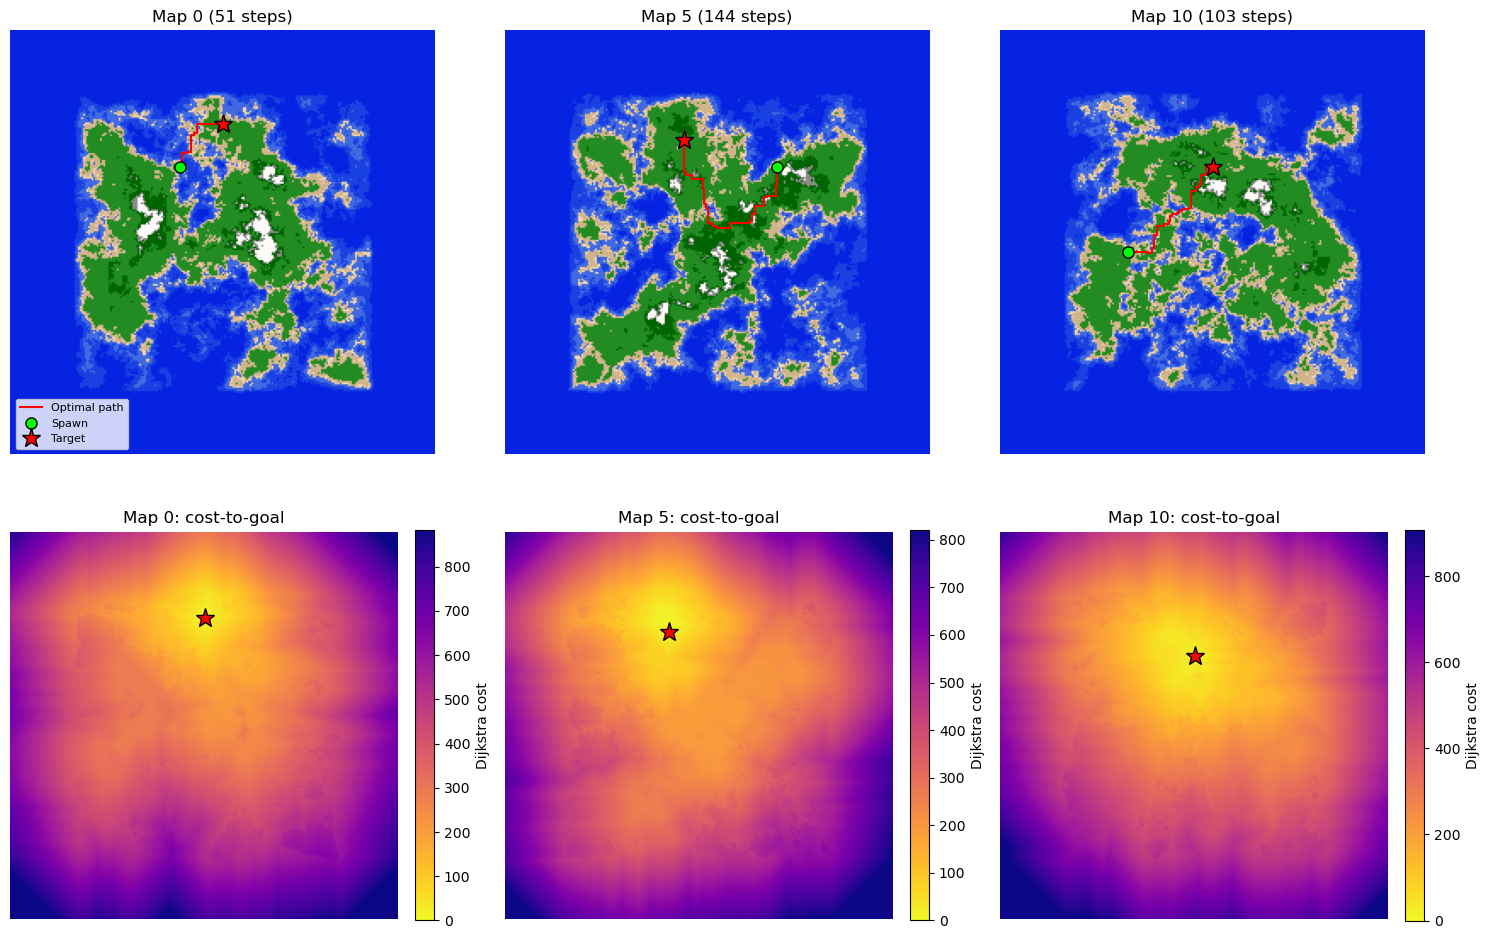

In [145]:
# Greedy path tracer on cost-to-go map
DELTAS = [(-1, 0), (1, 0), (0, 1), (0, -1)]


# Reverse Dijkstra with resource-aware costs
world_maps_t = torch.stack(maps)
targets_t = torch.tensor(targets, dtype=torch.long)

ctg_maps = []
for i in range(3):
    wm = maps[i].numpy()
    H, W = wm.shape
    graph = build_resource_aware_graph(wm, TERRAINS, config.reward.beta_raft)
    tr, tc = targets[i]
    target_idx = tr * W + tc
    dist = scipy_dijkstra(graph.T, directed=True, indices=target_idx)
    ctg_maps.append(dist.reshape(H, W))

paths = []
for i in range(3):
    p = trace_optimal_path(ctg_maps[i], spawns[i], targets[i])
    paths.append(p)
    print(f"Map {MAP_IDS[i]}: {len(p)} steps")

# Plot: top row = map + path, bottom row = cost-to-go heatmap
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, (m, p, sp, tg, mid, ctg) in enumerate(zip(maps, paths, spawns, targets, MAP_IDS, ctg_maps)):
    ax_map = axes[0, i]
    ax_ctg = axes[1, i]

    # Top: terrain map with optimal path overlay
    ax_map.imshow(colorize(m))
    cols = [c for r, c in p]
    rows = [r for r, c in p]
    ax_map.plot(cols, rows, "r-", linewidth=1.5, label="Optimal path")
    ax_map.plot(sp[1], sp[0], "o", color="lime", markersize=8, markeredgecolor="k", label="Spawn")
    ax_map.plot(tg[1], tg[0], "r*", markersize=14, markeredgecolor="k", label="Target")
    ax_map.set_title(f"Map {mid} ({len(p)} steps)", fontsize=12)
    ax_map.axis("off")

    # Bottom: Dijkstra cost-to-go heatmap (inf = unreachable, shown as black)
    ctg_display = np.where(np.isinf(ctg), np.nan, ctg)
    im = ax_ctg.imshow(ctg_display, cmap="plasma_r", origin="upper",
                       vmin=np.nanmin(ctg_display), vmax=np.nanpercentile(ctg_display, 98))
    ax_ctg.plot(tg[1], tg[0], "r*", markersize=14, markeredgecolor="k")
    ax_ctg.set_title(f"Map {mid}: cost-to-goal", fontsize=12)
    ax_ctg.axis("off")
    plt.colorbar(im, ax=ax_ctg, fraction=0.046, pad=0.04, label="Dijkstra cost")

axes[0, 0].legend(loc="lower left", fontsize=8, framealpha=0.8)
plt.tight_layout()
plt.show()

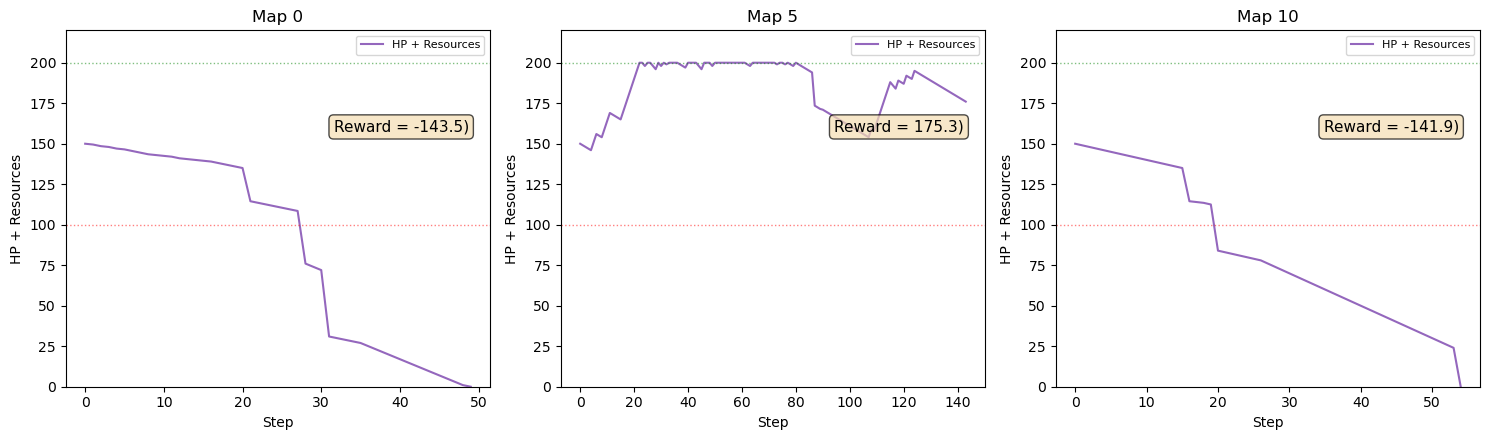

In [146]:
# Numpy arrays for compiled terrain data
compiled_np = dict(
    move_costs=move_costs_np, res_rate=res_rate_np, hp_rate=hp_rate_np,
    is_water=is_water_np, is_forest=is_forest_np, thresholds=thresholds_np,
)

# Run simulation and plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for i, (ax, path, m, mid) in enumerate(zip(axes, paths, maps, MAP_IDS)):
    hp_h, res_h, rew_h = simulate_walk(path, m, ctg_maps[i], config, compiled_np)
    steps = np.arange(len(hp_h))

    budget = hp_h + res_h
    ax.plot(steps, budget, color="tab:purple", linewidth=1.5, label="HP + Resources")
    ax.axhline(config.agent.max_hp + config.agent.max_resources, linestyle=":", color="green", alpha=0.5, linewidth=1)
    ax.axhline(100, linestyle=":", color="red", alpha=0.5, linewidth=1)
    ax.set_ylim(0, config.agent.max_hp + config.agent.max_resources + 20)
    ax.set_xlabel("Step")
    ax.set_ylabel("HP + Resources")
    ax.set_title(f"Map {mid}", fontsize=12)
    ax.legend(loc="upper right", fontsize=8)

    # Annotate cumulative reward
    ax.annotate(
        f"Reward = {rew_h[-1]:.1f})",
        xy=(0.95, 0.75), xycoords="axes fraction",
        ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.3", fc="wheat", alpha=0.7),
    )

plt.tight_layout()
plt.show()